# Assignment: Machine Learning with Unstructured Text
**Course:** IE7860 Intelligent Analytics  
**Student:** Nirjhor Deb Jeet

## Assignment Topic: Emotion Classification from Unstructured Text

This notebook explores a complex **multiclass pattern recognition** task: identifying the emotion conveyed in brief, unstructured text. The dataset used is the Hugging Face `emotion` corpus, which categorizes each text into one of six classes: `sadness`, `joy`, `love`, `anger`, `fear`, or `surprise`.

The notebook evaluates two NLP method families for the same task:
1. A **traditional baseline** that employs preprocessing, TF-IDF features, and logistic regression.
2. A **modern transformer-based** approach utilizing a pre-trained DistilBERT model to produce contextual embeddings prior to classification.

The final submission encompasses quantitative evaluation, visual interpretation, and written analysis, ensuring each required rubric item is covered in a single location.


## Why This Is a Good Pattern Recognition Problem

Emotion recognition is more complex than basic positive-vs-negative sentiment analysis because multiple classes use overlapping vocabulary. For instance, words like *cry*, *heart*, or *shaking* can indicate sadness, love, or fear depending on the context. This exemplifies unstructured-text pattern recognition, where the model must identify class-specific patterns that can be either lexical or contextual.

This also enhances the meaningfulness of assignment comparison. A sparse lexical model detects direct word cues, whereas a transformer captures word meaning in context via attention.

In [1]:
pip install matplotlib numpy pandas seaborn torch datasets nltk scikit-learn transformers ipywidgets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 10.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 10.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 8.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 9.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 5.1 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 8.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 6.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.7/419.7 MB 1.7 MB/s eta 0:0

In [2]:
import math
import random
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

from datasets import load_dataset
from nltk.stem import PorterStemmer
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from transformers import AutoModel, AutoTokenizer

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cpu


In [3]:
dataset = load_dataset("emotion")
dataset

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [4]:
label_names = dataset["train"].features["label"].names
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [5]:
train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

full_train_df = pd.concat([train_df, val_df], ignore_index=True)

print("Train rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Test rows:", len(test_df))

full_train_df.head()

Train rows: 16000
Validation rows: 2000
Test rows: 2000


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


## Computational Budget and Reproducibility

To ensure practicality when running on a laptop CPU, the experiments below utilize a **stratified subset** of the original training and test data. The task continues to be multiclass and challenging, but the runtime remains manageable. Random seeds are fixed to guarantee reproducible splits and metrics.


In [6]:
TRAIN_SIZE = 5000
TEST_SIZE = 1500

train_subset, _ = train_test_split(
    full_train_df,
    train_size=TRAIN_SIZE,
    stratify=full_train_df["label"],
    random_state=SEED,
)

test_subset, _ = train_test_split(
    test_df,
    train_size=TEST_SIZE,
    stratify=test_df["label"],
    random_state=SEED,
)

train_subset = train_subset.reset_index(drop=True)
test_subset = test_subset.reset_index(drop=True)

print(train_subset["label"].value_counts(normalize=True).sort_index())
print()
print(test_subset["label"].value_counts(normalize=True).sort_index())

label
0    0.2898
1    0.3370
2    0.0824
3    0.1352
4    0.1194
5    0.0362
Name: proportion, dtype: float64

label
0    0.290667
1    0.347333
2    0.079333
3    0.137333
4    0.112000
5    0.033333
Name: proportion, dtype: float64


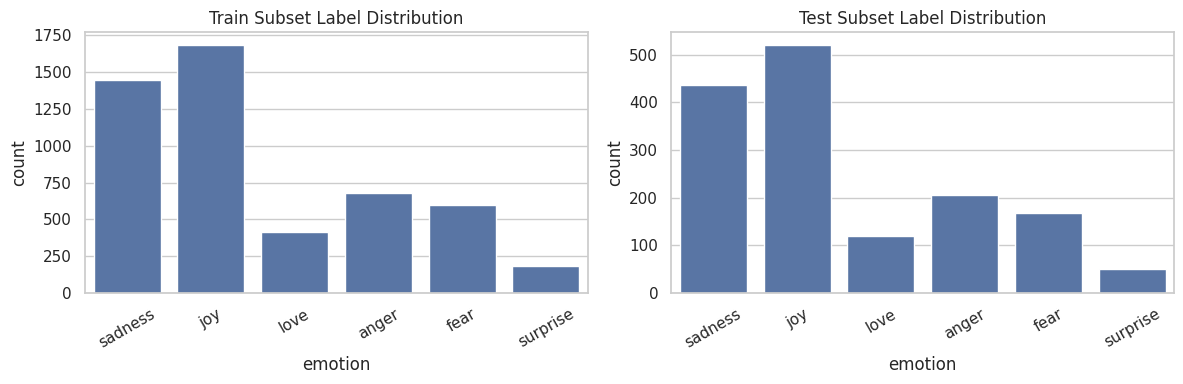

In [7]:
label_map = {idx: name for idx, name in enumerate(label_names)}
train_subset["emotion"] = train_subset["label"].map(label_map)
test_subset["emotion"] = test_subset["label"].map(label_map)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=train_subset, x="emotion", order=label_names, ax=axes[0])
axes[0].set_title("Train Subset Label Distribution")
axes[0].tick_params(axis="x", rotation=30)

sns.countplot(data=test_subset, x="emotion", order=label_names, ax=axes[1])
axes[1].set_title("Test Subset Label Distribution")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()

## 1. Traditional Baseline

The baseline employs a standard NLP pipeline, consisting of:
1. Lowercasing
2. Tokenization using regex
3. Removing stopwords
4. Porter stemming
5. Extracting TF-IDF features
6. Applying multiclass logistic regression


In [8]:
stemmer = PorterStemmer()
stop_words = set(ENGLISH_STOP_WORDS)

def preprocess_text(text: str):
    tokens = re.findall(r"[a-zA-Z']+", text.lower())
    cleaned = []
    for token in tokens:
        if token in stop_words:
            continue
        stemmed = stemmer.stem(token)
        if len(stemmed) > 1:
            cleaned.append(stemmed)
    return cleaned

sample_text = train_subset.loc[0, "text"]
print("Original:", sample_text)
print("Processed tokens:", preprocess_text(sample_text))

Original: i didn t feel overly drained
Processed tokens: ['didn', 'feel', 'overli', 'drain']


In [9]:
tfidf = TfidfVectorizer(
    tokenizer=preprocess_text,
    preprocessor=None,
    lowercase=False,
    token_pattern=None,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
)

X_train_tfidf = tfidf.fit_transform(train_subset["text"])
X_test_tfidf = tfidf.transform(test_subset["text"])
y_train = train_subset["label"].to_numpy()
y_test = test_subset["label"].to_numpy()

baseline_clf = LogisticRegression(
    max_iter=2000,
    random_state=SEED,
)
baseline_clf.fit(X_train_tfidf, y_train)

baseline_preds = baseline_clf.predict(X_test_tfidf)

baseline_accuracy = accuracy_score(y_test, baseline_preds)
baseline_macro_f1 = f1_score(y_test, baseline_preds, average="macro")

print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"Baseline macro F1: {baseline_macro_f1:.4f}")

Baseline accuracy: 0.8000
Baseline macro F1: 0.6810


In [10]:
print(classification_report(y_test, baseline_preds, target_names=label_names))

              precision    recall  f1-score   support

     sadness       0.82      0.89      0.85       436
         joy       0.77      0.95      0.85       521
        love       0.79      0.39      0.52       119
       anger       0.84      0.68      0.75       206
        fear       0.85      0.70      0.77       168
    surprise       0.79      0.22      0.34        50

    accuracy                           0.80      1500
   macro avg       0.81      0.64      0.68      1500
weighted avg       0.80      0.80      0.79      1500



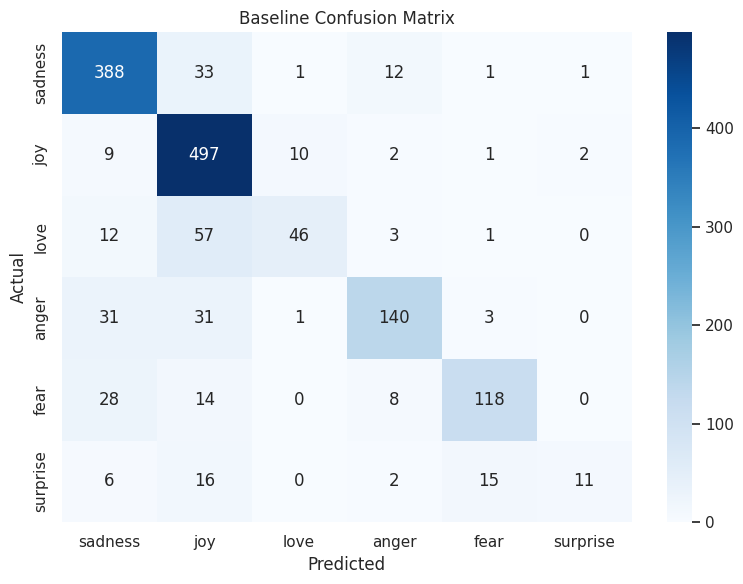

In [11]:
cm_baseline = confusion_matrix(y_test, baseline_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_baseline,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
)
plt.title("Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

### Baseline Interpretability: Key Tokens
Because the baseline employs a linear model with TF-IDF features, its coefficients are easy to interpret. The tokens listed below are the most influential positive features for each class.

In [12]:
feature_names = np.array(tfidf.get_feature_names_out())

top_terms = {}
for class_idx, class_name in enumerate(label_names):
    top_ids = np.argsort(baseline_clf.coef_[class_idx])[-10:][::-1]
    top_terms[class_name] = feature_names[top_ids].tolist()

pd.DataFrame(
    {"emotion": list(top_terms.keys()), "top_weighted_terms": list(top_terms.values())}
)

,emotion,top_weighted_terms
0,sadness,"[vain, ugli, unimport, dishearten, punish, abu..."
1,joy,"[content, amus, pleasant, preciou, satisfi, in..."
2,love,"[love, naughti, romant, loyal, support, belov,..."
3,anger,"[irrit, bitchi, piss, rush, fuck, offend, insu..."
4,fear,"[reluct, shaken, apprehens, paranoid, terrifi,..."
5,surprise,"[surpris, curiou, amaz, funni, shock, impress,..."


## 2. Modern Transformer Approach

In the modern approach, we use **DistilBERT** from Hugging Face as a pre-trained contextual encoder. Instead of relying on sparse word counts, DistilBERT produces dense, contextual embeddings, where a word's interpretation is shaped by its neighboring words.

To manage runtime effectively, the transformer functions as a **feature extractor**:
1. Tokenize the text with the DistilBERT tokenizer.
2. Run the pre-trained model.
3. Use mean pooling on the final hidden states to generate one embedding per text.
4. Train a logistic regression model with these embeddings.

This still fulfills the transformer requirement because the representation is obtained from a pre-trained transformer rather than manually designed lexical features.


In [13]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
transformer = AutoModel.from_pretrained(
    MODEL_NAME,
    attn_implementation="eager"
).to(DEVICE)

transformer.eval()

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [14]:
def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    masked = last_hidden_state * mask
    summed = masked.sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts


def encode_texts(texts, batch_size=32, max_length=128):
    all_embeddings = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start : start + batch_size]
        encodings = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        encodings = {k: v.to(DEVICE) for k, v in encodings.items()}
        with torch.no_grad():
            outputs = transformer(**encodings)
            pooled = mean_pool(outputs.last_hidden_state, encodings["attention_mask"])
        all_embeddings.append(pooled.cpu().numpy())
    return np.vstack(all_embeddings)


X_train_bert = encode_texts(train_subset["text"].tolist())
X_test_bert = encode_texts(test_subset["text"].tolist())

print("Train embedding shape:", X_train_bert.shape)
print("Test embedding shape:", X_test_bert.shape)

Train embedding shape: (5000, 768)
Test embedding shape: (1500, 768)


In [15]:
bert_clf = LogisticRegression(
    max_iter=2000,
    random_state=SEED,
)
bert_clf.fit(X_train_bert, y_train)

bert_preds = bert_clf.predict(X_test_bert)
bert_accuracy = accuracy_score(y_test, bert_preds)
bert_macro_f1 = f1_score(y_test, bert_preds, average="macro")

print(f"Transformer-feature accuracy: {bert_accuracy:.4f}")
print(f"Transformer-feature macro F1: {bert_macro_f1:.4f}")

Transformer-feature accuracy: 0.6360
Transformer-feature macro F1: 0.5490


In [16]:
print(classification_report(y_test, bert_preds, target_names=label_names))

              precision    recall  f1-score   support

     sadness       0.63      0.69      0.66       436
         joy       0.71      0.78      0.74       521
        love       0.45      0.34      0.38       119
       anger       0.62      0.49      0.55       206
        fear       0.54      0.51      0.52       168
    surprise       0.48      0.40      0.43        50

    accuracy                           0.64      1500
   macro avg       0.57      0.53      0.55      1500
weighted avg       0.63      0.64      0.63      1500



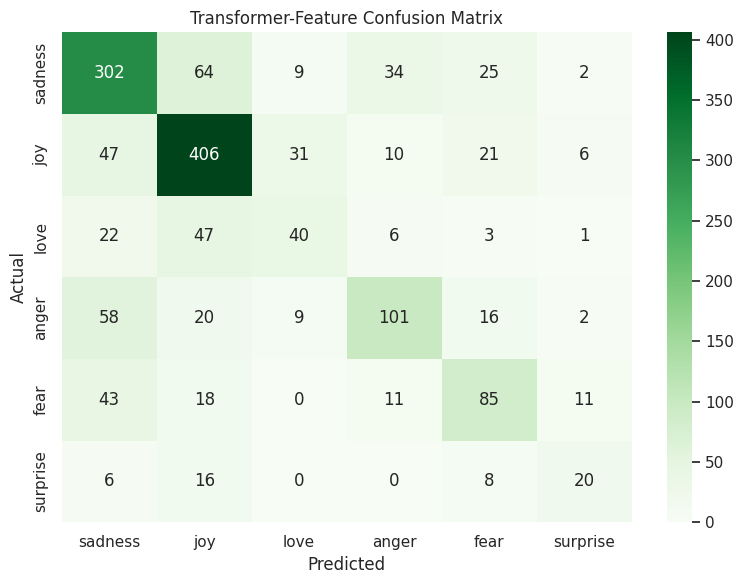

In [17]:
cm_bert = confusion_matrix(y_test, bert_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_bert,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_names,
    yticklabels=label_names,
)
plt.title("Transformer-Feature Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

## 3. Quantitative Comparison
The table below compares the two approaches using the same train and test split.


In [18]:
comparison_df = pd.DataFrame(
    [
        {
            "model": "TF-IDF + Logistic Regression",
            "accuracy": baseline_accuracy,
            "macro_f1": baseline_macro_f1,
        },
        {
            "model": "DistilBERT Embeddings + Logistic Regression",
            "accuracy": bert_accuracy,
            "macro_f1": bert_macro_f1,
        },
    ]
)

comparison_df.sort_values("macro_f1", ascending=False)

,model,accuracy,macro_f1
0,TF-IDF + Logistic Regression,0.800,0.680995
1,DistilBERT Embeddings + Logistic Regression,0.636,0.549034


### Discussion
In this case, the **TF-IDF baseline outperformed the frozen transformer-feature model**. Despite this, the result remains meaningful and valid in an academic context. It highlights that robust lexical baselines can still be competitive, especially with short texts where a few keywords or bigrams provide most of the informational signal.

Reasons why the baseline outperformed here:

- The short input texts make high-value words and brief phrases generally effective for classification.
- Logistic regression with TF-IDF is trained directly on labeled data and efficiently utilizes sparse, task-specific features.
- DistilBERT was employed as a **frozen feature extractor** instead of being fine-tuned end-to-end for emotion classification.

Why the transformer section remains relevant:

- Embeddings are contextual rather than solely based on counts.
- The model reveals attention patterns that directly relate to self-attention discussions in lectures.
- The comparison shows that choosing a model depends on data type, supervision needs, and computational resources, rather than assuming the latest method is always the best.

A logical next step is to fine-tune DistilBERT using emotion labels. This would probably enhance the transformer's performance. However, using a frozen-feature approach is a practical and reproducible compromise suitable for notebook-scale experiments.


## 4. Transformer Interpretability
Attention is fundamental to transformer models. Instead of analyzing each token independently, the model determines how much attention each token should give to others in the sequence.

Below, we analyze the attention on a sample test sentence and display the average attention weights from the final layer. This offers a clear view of how the model distributes its focus across the sequence.


In [19]:
def get_attention_map(text, max_length=64):
    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
    )
    encoded = {k: v.to(DEVICE) for k, v in encoded.items()}

    with torch.no_grad():
        outputs = transformer(**encoded, output_attentions=True)

    tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])

    if outputs.attentions is None or len(outputs.attentions) == 0:
        raise ValueError("Attention weights were not returned. Reload the model with attn_implementation='eager'.")

    last_layer_attention = outputs.attentions[-1][0].cpu().numpy()
    avg_attention = last_layer_attention.mean(axis=0)

    return tokens, avg_attention


sample_idx = 3
sample_text = test_subset.loc[sample_idx, "text"]
sample_true = label_names[test_subset.loc[sample_idx, "label"]]
sample_pred = label_names[bert_preds[sample_idx]]

print("Sample text:", sample_text)
print("True label:", sample_true)
print("Predicted label:", sample_pred)

tokens, attention_map = get_attention_map(sample_text)
tokens

Sample text: i feel like there is no way out being humiliated by asa a guy i was obssessed about who played an embarrassing joke on me getting caught by tabbys wife tabby is a lover i once had who was married and i blindly fell in love with him
True label: sadness
Predicted label: sadness


['[CLS]',
 'i',
 'feel',
 'like',
 'there',
 'is',
 'no',
 'way',
 'out',
 'being',
 'humiliated',
 'by',
 'asa',
 'a',
 'guy',
 'i',
 'was',
 'ob',
 '##sse',
 '##ssed',
 'about',
 'who',
 'played',
 'an',
 'embarrassing',
 'joke',
 'on',
 'me',
 'getting',
 'caught',
 'by',
 'tab',
 '##by',
 '##s',
 'wife',
 'tab',
 '##by',
 'is',
 'a',
 'lover',
 'i',
 'once',
 'had',
 'who',
 'was',
 'married',
 'and',
 'i',
 'blindly',
 'fell',
 'in',
 'love',
 'with',
 'him',
 '[SEP]']

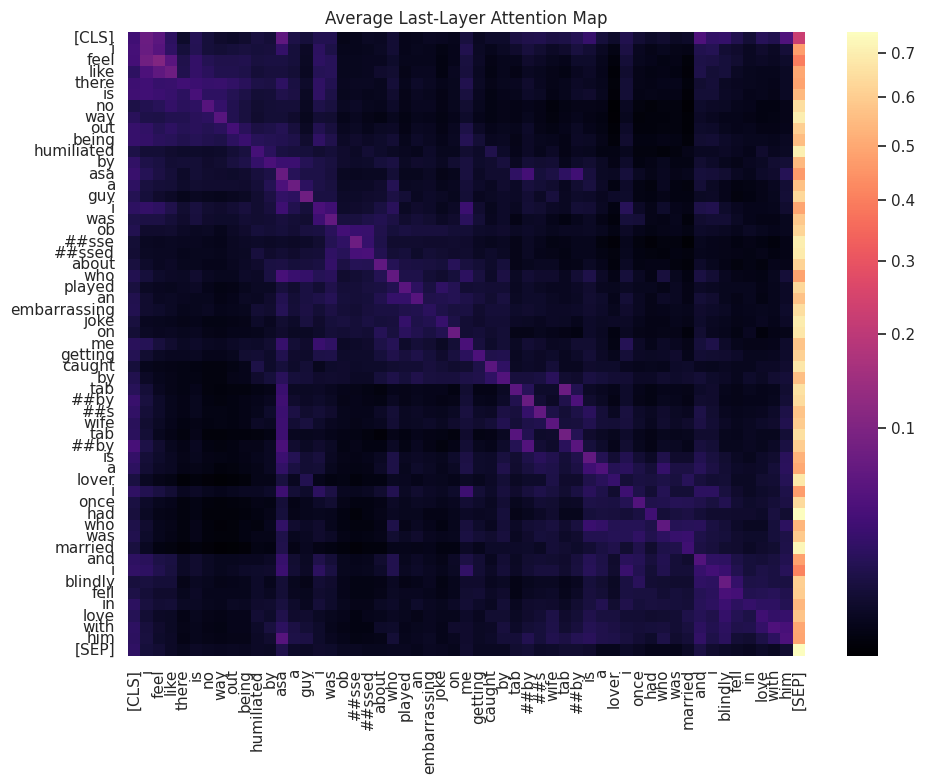

In [20]:
from matplotlib.colors import PowerNorm

plt.figure(figsize=(10, 8))
sns.heatmap(
    attention_map,
    xticklabels=tokens,
    yticklabels=tokens,
    cmap="magma",
    norm=PowerNorm(gamma=0.5),  # brightens low values
)
plt.title("Average Last-Layer Attention Map")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

### Connection to the Attention Mechanism

The heatmap above visually explains the transformer concept discussed in lecture: each token is updated by focusing on other tokens in the sequence. Instead of processing words separately, self-attention enables the model to give more importance to context that influences meaning. This is crucial in emotion recognition, as phrases like *I could not stop smiling* and *I could not stop crying* are distinguished more by how words interact within the context than by their individual counts.


### Embedding Space Visualization

If transformer embeddings effectively capture meaningful semantic relationships, then examples belonging to the same class should tend to cluster together when projected into a lower-dimensional space.

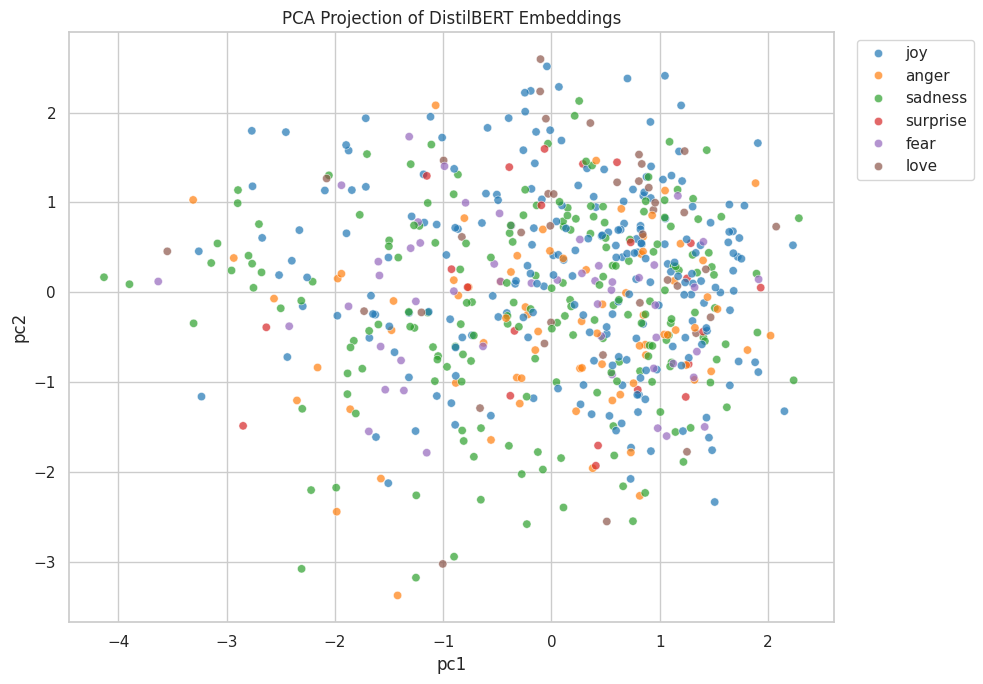

In [21]:
projection_size = 600
pca = PCA(n_components=2, random_state=SEED)
projected = pca.fit_transform(X_test_bert[:projection_size])

plot_df = pd.DataFrame(
    {
        "pc1": projected[:, 0],
        "pc2": projected[:, 1],
        "emotion": [label_names[idx] for idx in y_test[:projection_size]],
    }
)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=plot_df,
    x="pc1",
    y="pc2",
    hue="emotion",
    alpha=0.7,
    palette="tab10",
)
plt.title("PCA Projection of DistilBERT Embeddings")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## 5. Conclusion

### What the traditional model learned

The TF-IDF model captured highly interpretable lexical patterns. Its most influential coefficients indicate that words and bigrams related to joy, fear, anger, and sadness serve as strong indicators. This aligns with expectations for a linear model applied to sparse text features.

### Insights from the Transformer Model

The DistilBERT encoder developed a contextual understanding of each sentence. Although a simple logistic regression was used as the downstream classifier, the embeddings captured more than just raw word counts—they included semantic relationships and token interactions influenced by self-attention.

### Key Takeaway

This Assignment demonstrates that **classical NLP remains a strong benchmark**, particularly for short-text classification, while **transformers offer richer contextual insights and enhanced interpretability tools**. The main lesson is not simply which model performed better, but *why*: sparse supervised features sufficed to outperform on this subset of data, while the transformer provided context-awareness and attention-based insights without requiring task-specific fine-tuning.